In [1]:
import sys

sys.path.append("..")

import torch
import matplotlib.pyplot as plt
import numpy as np

from src.paths import Paths
from src.utils import (
    get_device,
    tensor_to_img,
    plot_image,
    initialize_resnet18,
    load_model_weights,
)
from src.data_manager import DataManager
from src.perturbations import Perturbations
from src import config
from src.explainers import IGExplainer, OcclusionExplainer
from src.xai_experiment import XAIExperiment

## Konfiguracja ogólna

In [2]:
dataset_name = "mnist"
sigma = 0.8

device = get_device()
empty_model = initialize_resnet18(pretrained=False)

paths = Paths()

model = load_model_weights(empty_model, paths.MNIST_MODEL, device)

data_manager = DataManager(paths.DATA_DIR)

test_data = data_manager.get_test_dataset(
    dataset_name=dataset_name,
    download=False,
)

class_names = data_manager.get_class_names(dataset_name=dataset_name)

perturbations = Perturbations(
    model=model,
    device=device,
)

## Wybór badanych przykładów

In [3]:
max_examples_per_class = 10

clean_examples = {class_id: [] for class_id in range(len(class_names))}

for image, label in test_data:
    if len(clean_examples[label]) >= max_examples_per_class:
        continue

    tensor = image.unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(tensor)
        pred = output.argmax(dim=1).item()

    if pred == label:
        clean_examples[label].append(image)

    if all(
        len(clean_examples[class_id]) >= max_examples_per_class
        for class_id in clean_examples
    ):
        break

clean_examples_vis = {
    class_id: clean_examples[class_id][0] for class_id in clean_examples
}

## Konfiguracja IG

In [4]:
ig_explainer = IGExplainer(model=model, device=device, config=config.IGConfig())
ig_experiment = XAIExperiment(
    model=model,
    device=device,
    class_names=class_names,
    clean_examples=clean_examples,
    explainer=ig_explainer,
    perturbations=perturbations,
)
ig_experiment_vis = XAIExperiment(
    model=model,
    device=device,
    class_names=class_names,
    clean_examples=clean_examples_vis,
    explainer=ig_explainer,
    perturbations=perturbations,
)

ig_classes = ig_experiment_vis.selected_classes

all_ig_attrs = []
for class_id in ig_classes:
    clean_tensor = ig_experiment_vis.get_clean_tensor(class_id)
    noised_tensor = ig_experiment_vis.get_perturbed_tensor(
        clean_tensor=clean_tensor,
        class_id=class_id,
        perturbation_type="gaussian",
        value=sigma,
    )

    clean_attr = ig_experiment_vis.explainer.explain(
        input_tensor=clean_tensor, target_class=class_id
    )["abs"]

    noised_attr = ig_experiment_vis.explainer.explain(
        input_tensor=noised_tensor, target_class=class_id
    )["abs"]

    all_ig_attrs.append(clean_attr)
    all_ig_attrs.append(noised_attr)

ig_vmin = 0
ig_vmax = np.percentile([attr.flatten() for attr in all_ig_attrs], 99)


## Czyste obrazy

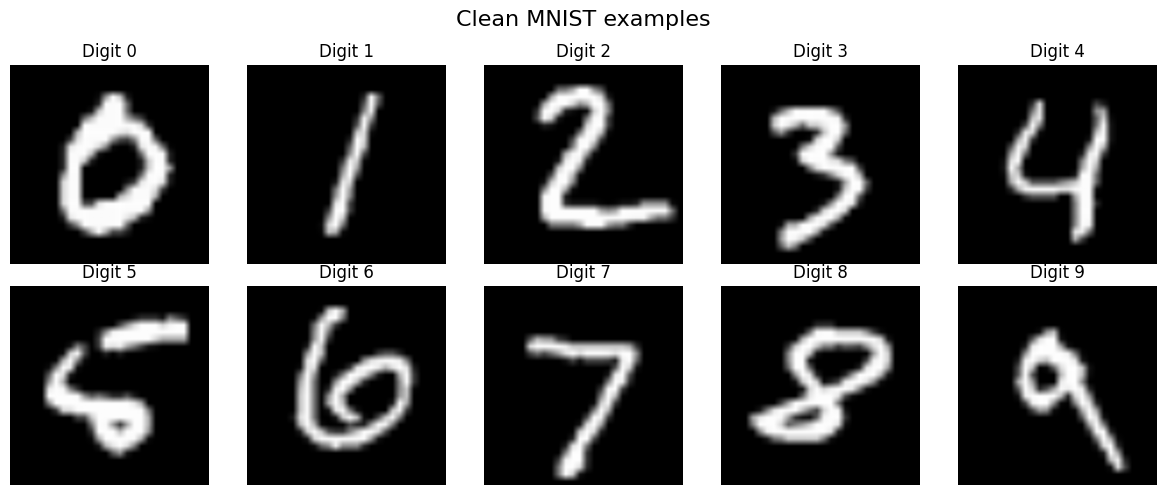

In [5]:
fig, axes = plt.subplots(
    2,
    5,
    figsize=(12, 5),
)

fig.suptitle("Clean MNIST examples", fontsize=16)

for idx, class_id in enumerate(ig_classes):
    row, col = divmod(idx, 5)

    clean_tensor = ig_experiment_vis.get_clean_tensor(class_id, to_device=False)

    plot_image(
        axes[row, col],
        tensor_to_img(clean_tensor),
        title=f"Digit {ig_experiment_vis.class_names[class_id]}",
        cmap="gray",
    )

plt.tight_layout()
plt.show()

## IG dla niezaszumionych danych

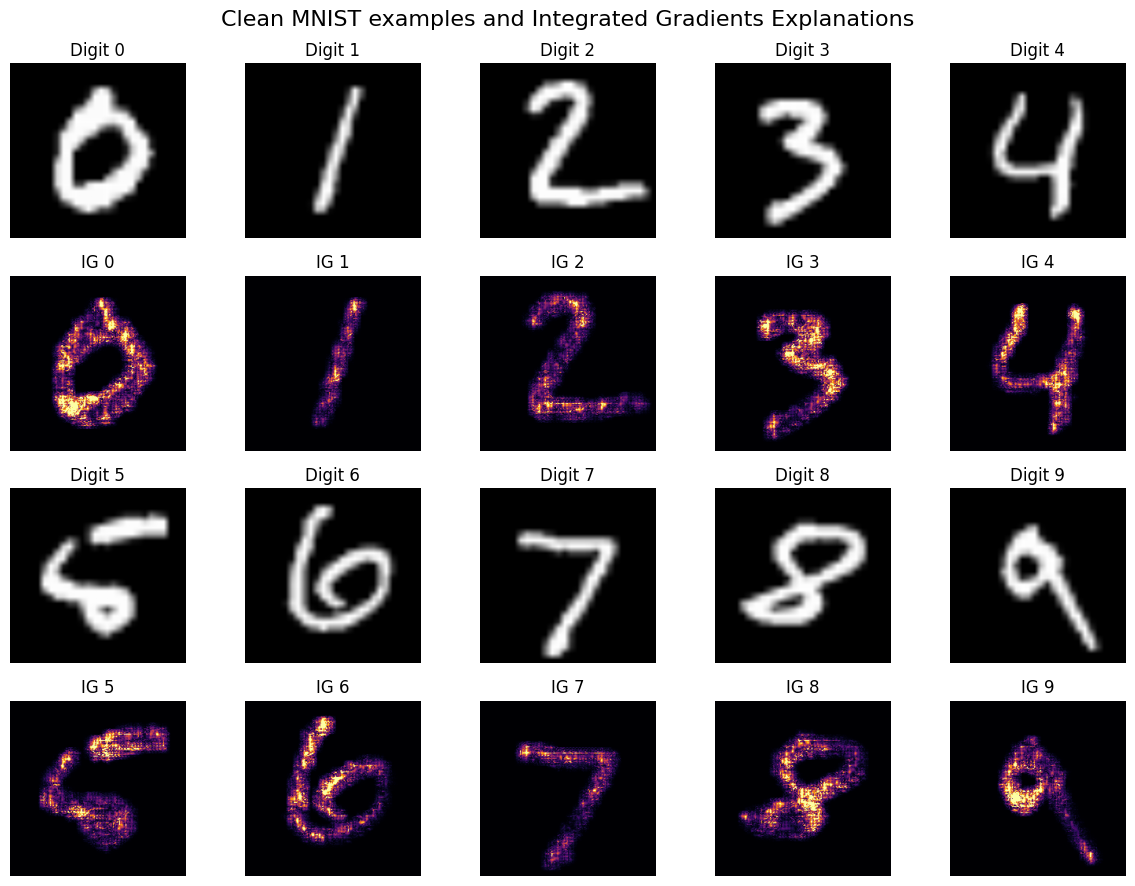

In [6]:
fig, axes = plt.subplots(
    4,
    5,
    figsize=(12, 9),
)

fig.suptitle(
    "Clean MNIST examples and Integrated Gradients Explanations",
    fontsize=16,
)

for idx, class_id in enumerate(ig_classes):
    block, col = divmod(idx, 5)

    clean_tensor = ig_experiment_vis.get_clean_tensor(class_id)
    clean_img = tensor_to_img(clean_tensor)

    attr_ig = ig_experiment_vis.explainer.explain(
        input_tensor=clean_tensor,
        target_class=class_id,
    )["abs"]

    plot_image(
        axes[block * 2, col],
        clean_img,
        title=f"Digit {class_names[class_id]}",
        cmap="gray",
    )

    plot_image(
        axes[block * 2 + 1, col],
        attr_ig,
        title=f"IG {class_names[class_id]}",
        cmap="inferno",
        vmin=ig_vmin,
        vmax=ig_vmax,
    )

plt.tight_layout()
plt.show()

## Szum Gaussa - prezentacja

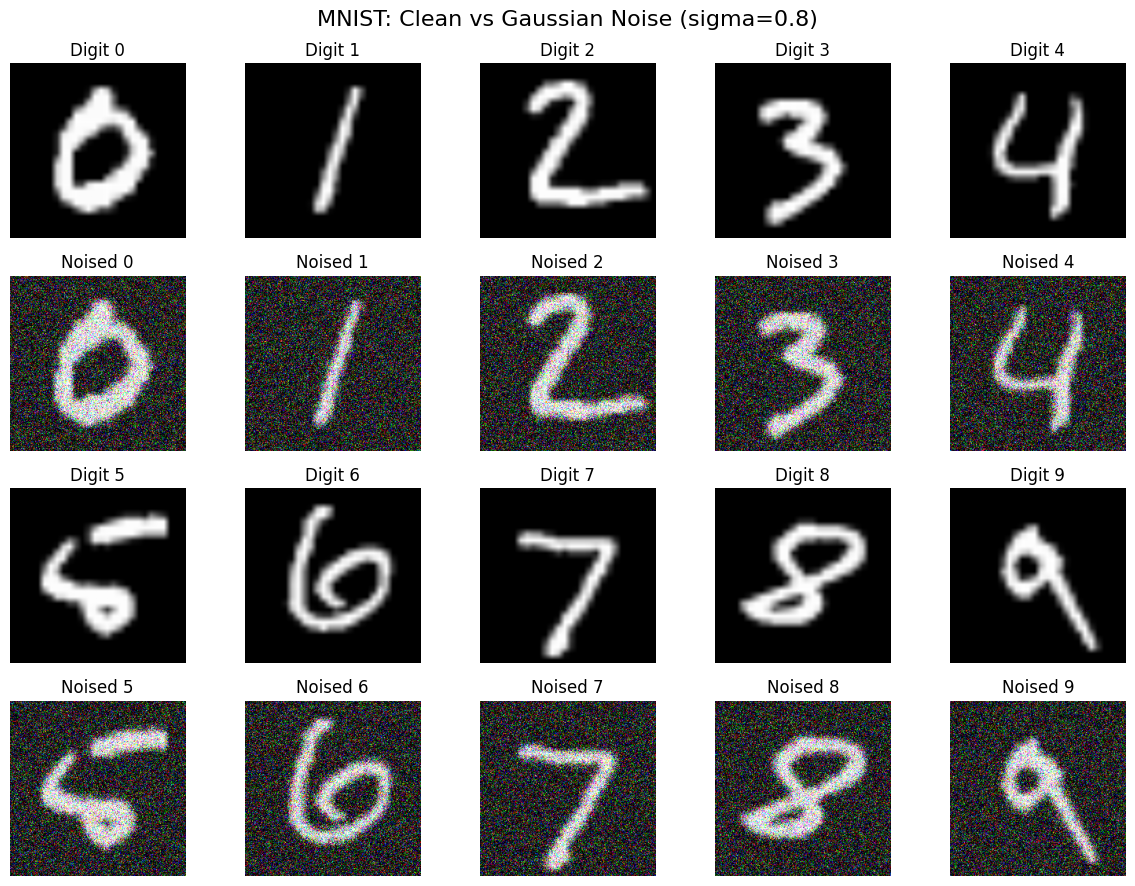

In [7]:
fig, axes = plt.subplots(
    4,
    5,
    figsize=(12, 9),
)

fig.suptitle(
    f"MNIST: Clean vs Gaussian Noise (sigma={sigma})",
    fontsize=16,
)

for idx, class_id in enumerate(ig_classes):
    block, col = divmod(idx, 5)

    clean_tensor = ig_experiment_vis.get_clean_tensor(
        class_id,
        to_device=False,
    )

    noised_tensor = perturbations.gaussian(
        input_tensor=clean_tensor,
        sigma=sigma,
    )

    plot_image(
        axes[block * 2, col],
        tensor_to_img(clean_tensor),
        title=f"Digit {class_names[class_id]}",
        cmap="gray",
    )

    plot_image(
        axes[block * 2 + 1, col],
        tensor_to_img(noised_tensor),
        title=f"Noised {class_names[class_id]}",
        cmap="gray",
    )

plt.tight_layout()
plt.show()

## IG danych niezaszumionych oraz zaszumionych

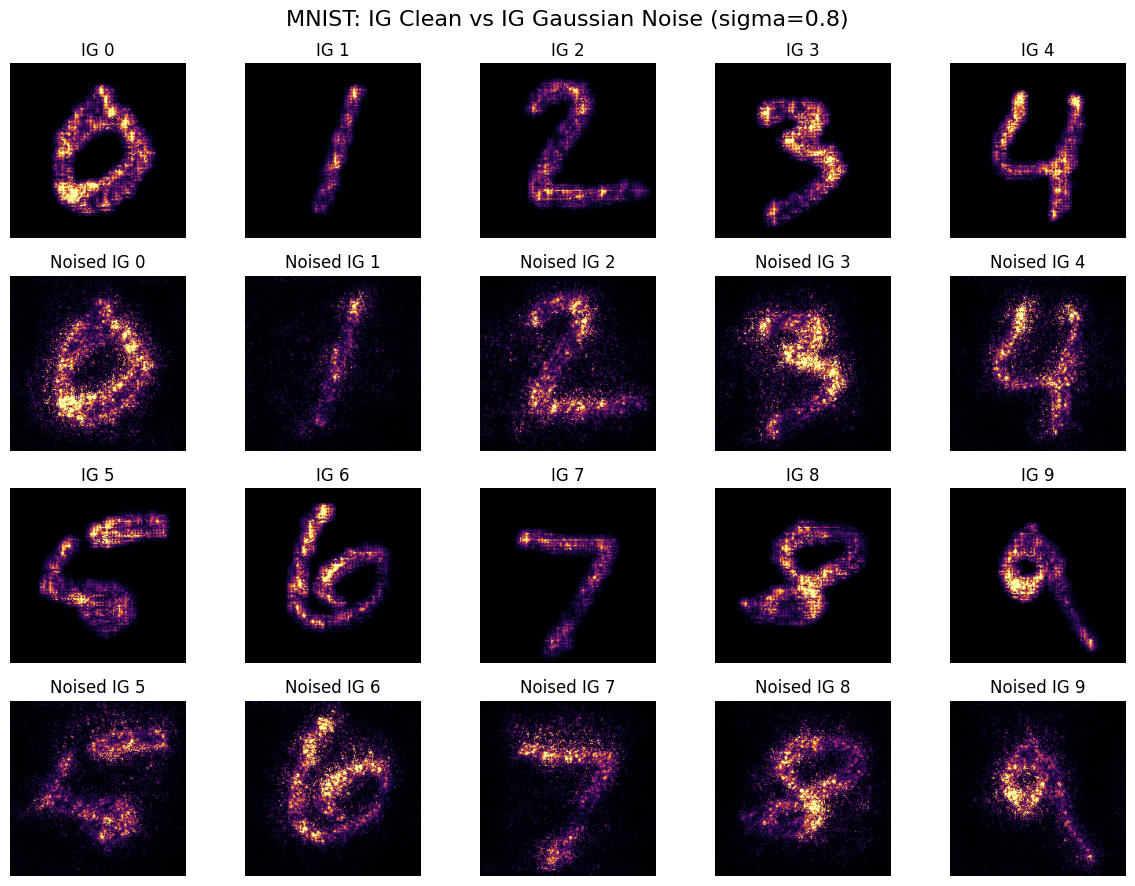

In [8]:
fig, axes = plt.subplots(
    4,
    5,
    figsize=(12, 9),
)

fig.suptitle(
    f"MNIST: IG Clean vs IG Gaussian Noise (sigma={sigma})",
    fontsize=16,
)

for idx, class_id in enumerate(ig_classes):
    block, col = divmod(idx, 5)

    clean_tensor = ig_experiment_vis.get_clean_tensor(class_id)

    noised_tensor = ig_experiment_vis.perturbations.gaussian(
        input_tensor=clean_tensor,
        sigma=sigma,
    )

    clean_attr = ig_experiment_vis.explainer.explain(
        input_tensor=clean_tensor,
        target_class=class_id,
    )["abs"]

    noised_attr = ig_experiment_vis.explainer.explain(
        input_tensor=noised_tensor,
        target_class=class_id,
    )["abs"]

    plot_image(
        axes[block * 2, col],
        clean_attr,
        title=f"IG {class_names[class_id]}",
        cmap="inferno",
        vmin=ig_vmin,
        vmax=ig_vmax,
    )

    plot_image(
        axes[block * 2 + 1, col],
        noised_attr,
        title=f"Noised IG {class_names[class_id]}",
        cmap="inferno",
        vmin=ig_vmin,
        vmax=ig_vmax,
    )

plt.tight_layout()
plt.show()

## Cosine Similarity oraz TopK IoU (IG)

In [9]:
df_similarity = ig_experiment.run_similarity_metrics(
    perturbation_type="gaussian",
    values=config.ExperimentConfig().gaussian_sigmas,
)

display(
    ig_experiment.make_pivot(
        df_similarity,
        "CosineSimilarity",
    ).round(3)
)

display(
    ig_experiment.make_pivot(
        df_similarity,
        "TopK_IoU",
    ).round(3)
)

display(ig_experiment.summarize_similarity(df_similarity).round(3))

Processing gaussian=0.01
Processing gaussian=0.03
Processing gaussian=0.05
Processing gaussian=0.075
Processing gaussian=0.1
Processing gaussian=0.15
Processing gaussian=0.2
Processing gaussian=0.3
Processing gaussian=0.5
Processing gaussian=0.8


ClassName,0,1,2,3,4,5,6,7,8,9
Value,,,,,,,,,,
0.010,0.932,0.938,0.948,0.941,0.947,0.946,0.948,0.932,0.941,0.940
0.030,0.891,0.901,0.899,0.885,0.907,0.893,0.902,0.888,0.888,0.894
0.050,0.869,0.873,0.869,0.863,0.887,0.866,0.874,0.861,0.865,0.861
0.075,0.847,0.864,0.852,0.846,0.868,0.848,0.850,0.843,0.840,0.846
0.100,0.832,0.849,0.832,0.829,0.855,0.829,0.837,0.824,0.825,0.823
0.150,0.816,0.834,0.811,0.813,0.834,0.806,0.821,0.804,0.804,0.810
0.200,0.803,0.814,0.798,0.797,0.813,0.794,0.805,0.792,0.787,0.794
0.300,0.776,0.783,0.775,0.775,0.786,0.769,0.781,0.762,0.769,0.774
0.500,0.738,0.711,0.719,0.743,0.743,0.722,0.733,0.710,0.726,0.733


ClassName,0,1,2,3,4,5,6,7,8,9
Value,,,,,,,,,,
0.010,0.706,0.898,0.792,0.779,0.779,0.794,0.807,0.792,0.774,0.821
0.030,0.619,0.855,0.696,0.698,0.707,0.705,0.720,0.718,0.677,0.741
0.050,0.582,0.828,0.661,0.665,0.677,0.669,0.687,0.683,0.629,0.702
0.075,0.555,0.802,0.638,0.640,0.656,0.646,0.660,0.667,0.599,0.683
0.100,0.537,0.775,0.621,0.622,0.637,0.627,0.643,0.649,0.581,0.669
0.150,0.516,0.736,0.593,0.598,0.611,0.598,0.619,0.624,0.555,0.645
0.200,0.497,0.705,0.575,0.578,0.585,0.577,0.601,0.602,0.539,0.619
0.300,0.466,0.645,0.537,0.546,0.542,0.544,0.567,0.562,0.513,0.593
0.500,0.426,0.565,0.476,0.503,0.484,0.481,0.515,0.489,0.470,0.540


,Value,CosineMean,CosineStd,TopKIoUMean,TopKIoUStd
0,0.010,0.941,0.018,0.794,0.069
1,0.030,0.895,0.017,0.714,0.078
2,0.050,0.869,0.018,0.678,0.080
3,0.075,0.850,0.016,0.654,0.082
4,0.100,0.834,0.019,0.636,0.079
5,0.150,0.815,0.017,0.609,0.076
6,0.200,0.800,0.015,0.588,0.073
7,0.300,0.775,0.015,0.552,0.065
8,0.500,0.728,0.023,0.495,0.056
9,0.800,0.665,0.028,0.424,0.051


## Deletion AUC (IG)

In [10]:
df_deletion = ig_experiment.run_deletion_auc(
    perturbation_type="gaussian",
    values=config.ExperimentConfig().gaussian_sigmas,
)

display(
    ig_experiment.make_pivot(
        df_deletion,
        "DeletionAUC_Perturbed",
    ).round(3)
)

display(ig_experiment.summarize_deletion(df_deletion).round(3))

Processing gaussian=0.01
Processing gaussian=0.03
Processing gaussian=0.05
Processing gaussian=0.075
Processing gaussian=0.1
Processing gaussian=0.15
Processing gaussian=0.2
Processing gaussian=0.3
Processing gaussian=0.5
Processing gaussian=0.8


ClassName,0,1,2,3,4,5,6,7,8,9
Value,,,,,,,,,,
0.010,0.460,0.921,0.417,0.193,0.548,0.588,0.452,0.817,0.439,0.253
0.030,0.443,0.922,0.370,0.180,0.529,0.600,0.426,0.806,0.432,0.250
0.050,0.404,0.882,0.334,0.169,0.491,0.487,0.391,0.814,0.404,0.234
0.075,0.388,0.895,0.334,0.123,0.468,0.497,0.367,0.783,0.345,0.187
0.100,0.351,0.866,0.265,0.097,0.411,0.456,0.309,0.723,0.295,0.186
0.150,0.283,0.827,0.189,0.069,0.300,0.327,0.215,0.641,0.230,0.143
0.200,0.253,0.802,0.137,0.053,0.221,0.208,0.161,0.525,0.145,0.085
0.300,0.169,0.736,0.093,0.037,0.104,0.116,0.076,0.307,0.093,0.051
0.500,0.113,0.696,0.067,0.027,0.060,0.081,0.043,0.182,0.059,0.039


,Value,CleanAUCMean,CleanAUCStd,PerturbedAUCMean,PerturbedAUCStd,CleanTargetConfidenceMean,PerturbedTargetConfidenceMean,PredictionChanges
0,0.010,0.308,0.242,0.509,0.299,0.999,0.999,0
1,0.030,0.308,0.242,0.496,0.300,0.999,0.999,0
2,0.050,0.308,0.242,0.461,0.295,0.999,0.999,0
3,0.075,0.308,0.242,0.439,0.307,0.999,0.999,0
4,0.100,0.308,0.242,0.396,0.297,0.999,0.999,0
5,0.150,0.308,0.242,0.322,0.280,0.999,0.999,0
6,0.200,0.308,0.242,0.259,0.258,0.999,0.998,0
7,0.300,0.308,0.242,0.178,0.217,0.999,0.997,0
8,0.500,0.308,0.242,0.137,0.200,0.999,0.989,0
9,0.800,0.308,0.242,0.112,0.162,0.999,0.908,6


## Konfiguracja Occlusion

In [11]:
occ_explainer = OcclusionExplainer(
    model=model, device=device, config=config.OcclusionConfig(), dataset=dataset_name
)
occ_experiment = XAIExperiment(
    model=model,
    device=device,
    class_names=class_names,
    clean_examples=clean_examples,
    explainer=occ_explainer,
    perturbations=perturbations,
)
occ_experiment_vis = XAIExperiment(
    model=model,
    device=device,
    class_names=class_names,
    clean_examples=clean_examples_vis,
    explainer=occ_explainer,
    perturbations=perturbations,
)

occ_classes = occ_experiment_vis.selected_classes

all_occ_attrs = []
for class_id in occ_classes:
    clean_tensor = occ_experiment_vis.get_clean_tensor(class_id)
    noised_tensor = occ_experiment_vis.get_perturbed_tensor(
        clean_tensor=clean_tensor,
        class_id=class_id,
        perturbation_type="gaussian",
        value=sigma,
    )

    clean_attr = occ_experiment_vis.explainer.explain(
        input_tensor=clean_tensor, target_class=class_id
    )["raw"]

    noised_attr = occ_experiment_vis.explainer.explain(
        input_tensor=noised_tensor, target_class=class_id
    )["raw"]

    all_occ_attrs.append(clean_attr)
    all_occ_attrs.append(noised_attr)

occ_vmin = min(attr.min() for attr in all_occ_attrs)
occ_vmax = max(attr.max() for attr in all_occ_attrs)


## Occlusion dla niezaszumionych danych

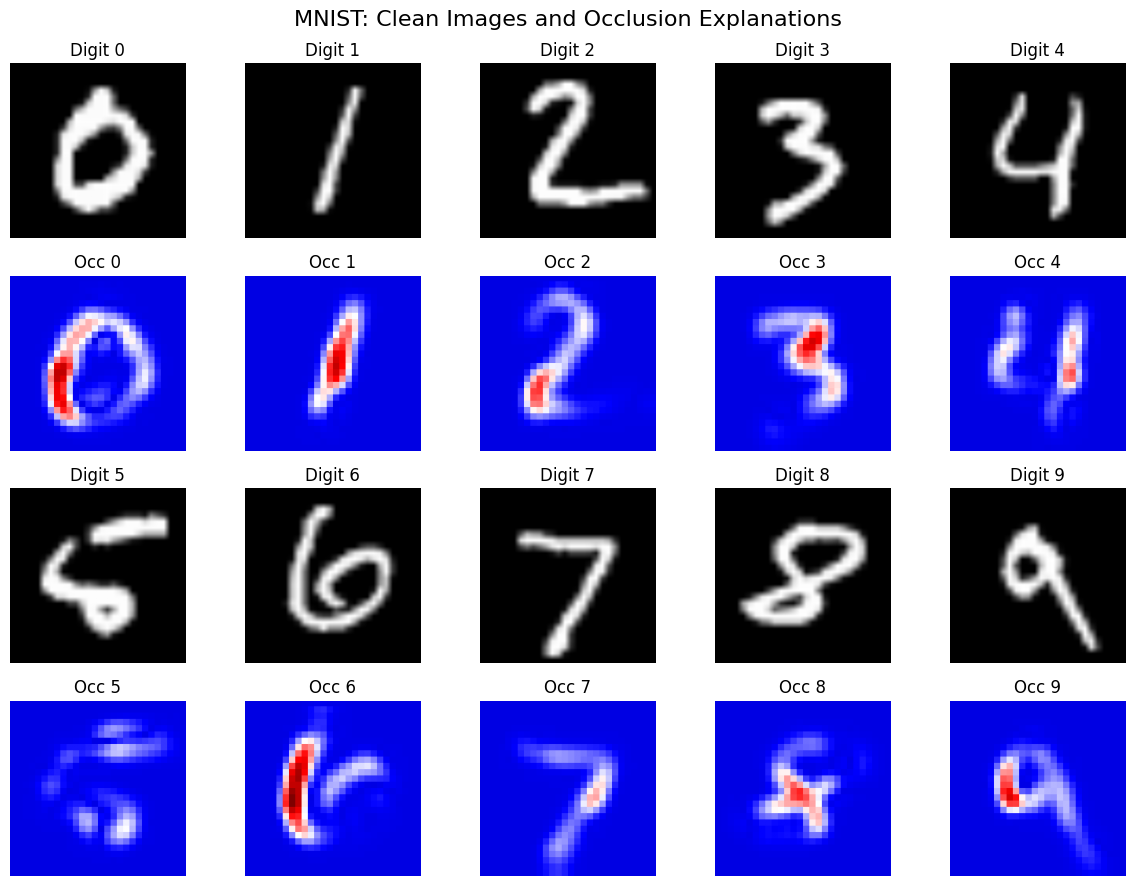

In [12]:
fig, axes = plt.subplots(
    4,
    5,
    figsize=(12, 9),
)

fig.suptitle(
    "MNIST: Clean Images and Occlusion Explanations",
    fontsize=16,
)

for idx, class_id in enumerate(occ_classes):
    block, col = divmod(idx, 5)

    clean_tensor = occ_experiment_vis.get_clean_tensor(class_id)

    attr_occ = occ_experiment_vis.explainer.explain(
        input_tensor=clean_tensor,
        target_class=class_id,
    )["abs"]

    plot_image(
        axes[block * 2, col],
        tensor_to_img(clean_tensor),
        title=f"Digit {occ_experiment_vis.class_names[class_id]}",
        cmap="gray",
    )

    plot_image(
        axes[block * 2 + 1, col],
        attr_occ,
        title=f"Occ {occ_experiment_vis.class_names[class_id]}",
        cmap="seismic",
        vmin=occ_vmin,
        vmax=occ_vmax,
    )

plt.tight_layout()
plt.show()

## Occlusion danych niezaszumionych oraz zaszumionych

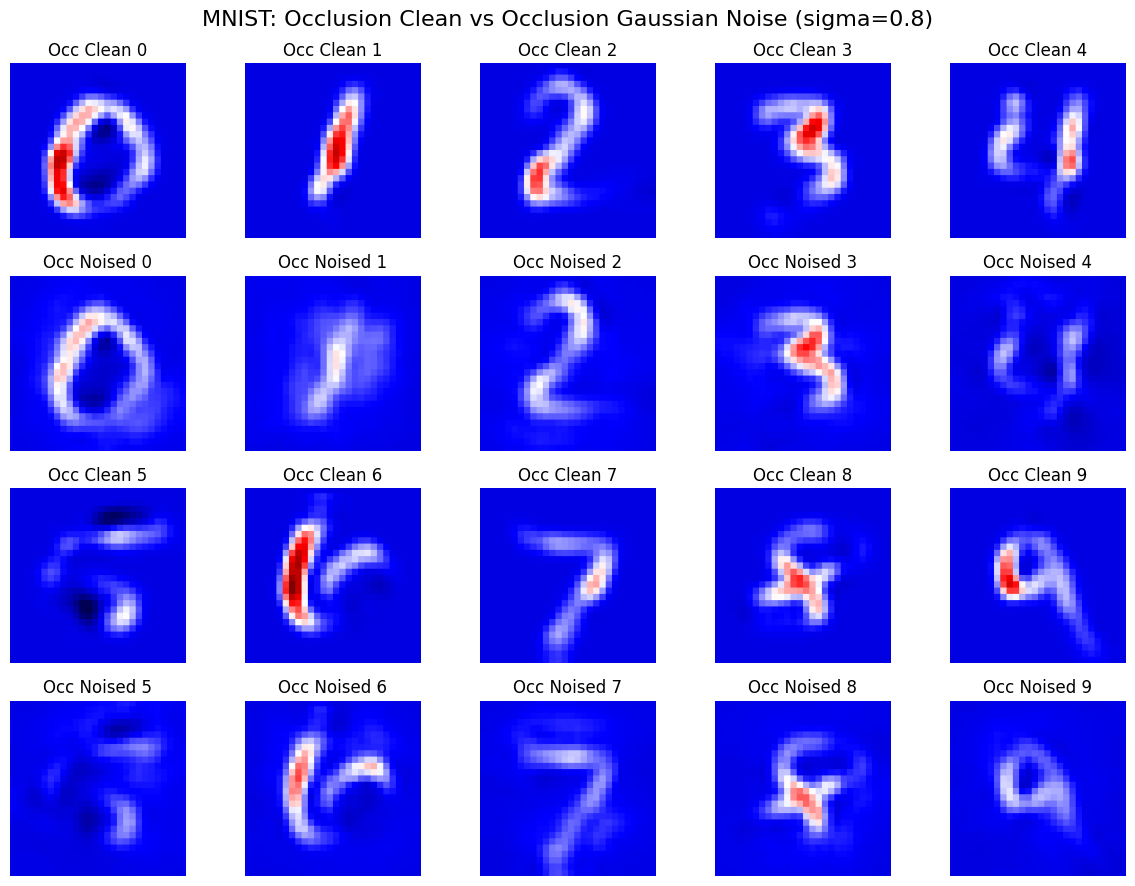

In [13]:
fig, axes = plt.subplots(
    4,
    5,
    figsize=(12, 9),
)

fig.suptitle(
    f"MNIST: Occlusion Clean vs Occlusion Gaussian Noise (sigma={sigma})",
    fontsize=16,
)

for idx, class_id in enumerate(occ_classes):
    block, col = divmod(idx, 5)

    clean_tensor = occ_experiment_vis.get_clean_tensor(class_id)

    noised_tensor = occ_experiment_vis.perturbations.gaussian(
        input_tensor=clean_tensor,
        sigma=sigma,
    )

    attr_occ_clean = occ_experiment_vis.explainer.explain(
        input_tensor=clean_tensor,
        target_class=class_id,
    )["raw"]

    attr_occ_noised = occ_experiment_vis.explainer.explain(
        input_tensor=noised_tensor,
        target_class=class_id,
    )["raw"]

    plot_image(
        axes[block * 2, col],
        attr_occ_clean,
        title=f"Occ Clean {occ_experiment_vis.class_names[class_id]}",
        cmap="seismic",
        vmin=occ_vmin,
        vmax=occ_vmax,
    )

    plot_image(
        axes[block * 2 + 1, col],
        attr_occ_noised,
        title=f"Occ Noised {occ_experiment_vis.class_names[class_id]}",
        cmap="seismic",
        vmin=occ_vmin,
        vmax=occ_vmax,
    )

plt.tight_layout()
plt.show()

## Cosine Similarity oraz TopK IoU (Occlusion)

In [14]:
df_occ_similarity = occ_experiment.run_similarity_metrics(
    perturbation_type="gaussian",
    values=config.ExperimentConfig().gaussian_sigmas,
)

display(
    occ_experiment.make_pivot(
        df_occ_similarity,
        "CosineSimilarity",
    ).round(3)
)

display(
    occ_experiment.make_pivot(
        df_occ_similarity,
        "TopK_IoU",
    ).round(3)
)

display(occ_experiment.summarize_similarity(df_occ_similarity).round(3))

Processing gaussian=0.01
Processing gaussian=0.03
Processing gaussian=0.05
Processing gaussian=0.075
Processing gaussian=0.1
Processing gaussian=0.15
Processing gaussian=0.2
Processing gaussian=0.3
Processing gaussian=0.5
Processing gaussian=0.8


ClassName,0,1,2,3,4,5,6,7,8,9
Value,,,,,,,,,,
0.010,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000
0.030,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000
0.050,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000
0.075,1.000,1.000,0.999,1.000,0.999,0.999,1.000,0.999,1.000,1.000
0.100,0.999,0.999,0.999,0.999,0.999,0.998,0.999,0.999,0.999,0.999
0.150,0.997,0.998,0.996,0.998,0.997,0.994,0.997,0.996,0.998,0.998
0.200,0.995,0.994,0.993,0.997,0.994,0.988,0.995,0.992,0.995,0.995
0.300,0.990,0.984,0.983,0.992,0.988,0.972,0.988,0.978,0.989,0.987
0.500,0.970,0.953,0.959,0.979,0.973,0.935,0.968,0.949,0.971,0.970


ClassName,0,1,2,3,4,5,6,7,8,9
Value,,,,,,,,,,
0.010,0.990,0.994,0.992,0.991,0.991,0.993,0.993,0.990,0.994,0.993
0.030,0.988,0.987,0.987,0.985,0.988,0.985,0.990,0.985,0.990,0.990
0.050,0.983,0.980,0.982,0.981,0.983,0.972,0.979,0.977,0.988,0.984
0.075,0.971,0.969,0.964,0.976,0.978,0.963,0.960,0.963,0.976,0.975
0.100,0.965,0.959,0.959,0.968,0.962,0.948,0.951,0.958,0.961,0.962
0.150,0.931,0.936,0.929,0.951,0.951,0.923,0.923,0.938,0.947,0.931
0.200,0.908,0.928,0.916,0.939,0.930,0.901,0.891,0.908,0.924,0.922
0.300,0.881,0.916,0.883,0.923,0.892,0.864,0.862,0.873,0.881,0.889
0.500,0.792,0.874,0.818,0.882,0.833,0.783,0.789,0.807,0.812,0.854


,Value,CosineMean,CosineStd,TopKIoUMean,TopKIoUStd
0,0.010,1.000,0.000,0.992,0.005
1,0.030,1.000,0.000,0.988,0.008
2,0.050,1.000,0.000,0.981,0.013
3,0.075,0.999,0.000,0.969,0.018
4,0.100,0.999,0.001,0.959,0.020
5,0.150,0.997,0.002,0.936,0.029
6,0.200,0.994,0.005,0.917,0.035
7,0.300,0.985,0.010,0.886,0.045
8,0.500,0.963,0.021,0.824,0.067
9,0.800,0.913,0.042,0.707,0.107


## Deletion AUC (Occlusion)

In [15]:
df_occ_deletion = occ_experiment.run_deletion_auc(
    perturbation_type="gaussian",
    values=config.ExperimentConfig().gaussian_sigmas,
)

display(
    occ_experiment.make_pivot(
        df_occ_deletion,
        "DeletionAUC_Perturbed",
    ).round(3)
)

display(occ_experiment.summarize_deletion(df_occ_deletion).round(3))

Processing gaussian=0.01
Processing gaussian=0.03
Processing gaussian=0.05
Processing gaussian=0.075
Processing gaussian=0.1
Processing gaussian=0.15
Processing gaussian=0.2
Processing gaussian=0.3
Processing gaussian=0.5
Processing gaussian=0.8


ClassName,0,1,2,3,4,5,6,7,8,9
Value,,,,,,,,,,
0.010,0.107,0.981,0.124,0.068,0.095,0.184,0.085,0.157,0.096,0.056
0.030,0.107,0.981,0.120,0.066,0.092,0.183,0.086,0.155,0.094,0.056
0.050,0.107,0.986,0.122,0.066,0.091,0.180,0.086,0.151,0.096,0.057
0.075,0.107,0.984,0.119,0.064,0.089,0.160,0.085,0.146,0.093,0.059
0.100,0.106,0.985,0.115,0.060,0.087,0.157,0.088,0.147,0.097,0.058
0.150,0.112,0.985,0.112,0.058,0.083,0.146,0.091,0.139,0.101,0.058
0.200,0.114,0.982,0.106,0.057,0.075,0.139,0.090,0.134,0.100,0.056
0.300,0.125,0.983,0.103,0.052,0.075,0.126,0.097,0.125,0.098,0.050
0.500,0.147,0.980,0.080,0.044,0.094,0.097,0.100,0.110,0.094,0.042


,Value,CleanAUCMean,CleanAUCStd,PerturbedAUCMean,PerturbedAUCStd,CleanTargetConfidenceMean,PerturbedTargetConfidenceMean,PredictionChanges
0,0.010,0.194,0.27,0.195,0.271,0.999,0.999,0
1,0.030,0.194,0.27,0.194,0.271,0.999,0.999,0
2,0.050,0.194,0.27,0.194,0.273,0.999,0.999,0
3,0.075,0.194,0.27,0.191,0.271,0.999,0.999,0
4,0.100,0.194,0.27,0.190,0.271,0.999,0.999,0
5,0.150,0.194,0.27,0.188,0.272,0.999,0.999,0
6,0.200,0.194,0.27,0.185,0.271,0.999,0.998,0
7,0.300,0.194,0.27,0.183,0.272,0.999,0.997,0
8,0.500,0.194,0.27,0.179,0.274,0.999,0.989,0
9,0.800,0.194,0.27,0.180,0.289,0.999,0.915,5
